# VQE Benchmark Framework
### Modular, reproducible VQE benchmark for molecular quantum chemistry

**Targets:** Qiskit 2.3.0 · Qiskit Nature 0.7+ · Qiskit Algorithms 0.3+  
**Molecules:** H₂, LiH, H₂O, CH₄, N₂, CO  
**Orbital spaces:** Full · Freeze Core · Active Space · FC + AS  
**Ansatze:** UCCSD · UCCGSD · k-UpCCGSD · HEA · ADAPT-VQE  

---
**Workflow cells:**  
1 Experiment Setup → 2 Molecular Problem → 3 Freeze Core (opt.) → 4 Active Space (opt.)  
→ 5 Fermionic Hamiltonian → 6 Qubit Mapping → 7 Build VQE → 8 Run VQE → 9 Analysis


## Cell 1 — Experiment Setup
Define all hyperparameters in one place. Change only this cell to switch molecules, mappers, ansatze, optimizers, and simulation modes.

In [20]:
# ============================================================
# CELL 1 — EXPERIMENT SETUP
# ============================================================

import sys
import os
import numpy as np
from pathlib import Path

# ── Resolve project paths ─────────────────────────────────
# HPC-safe: set PROJECT_ROOT eksplisit, tidak bergantung pada cwd
PROJECT_ROOT = Path("Project")   # ← ganti dengan path absolut kamu

SRC_DIR     = PROJECT_ROOT / "src"
CONFIGS_DIR = PROJECT_ROOT / "configs"
RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = PROJECT_ROOT/"tables"
# Verify
assert SRC_DIR.exists(),     f"SRC_DIR tidak ditemukan: {SRC_DIR}"
assert CONFIGS_DIR.exists(), f"CONFIGS_DIR tidak ditemukan: {CONFIGS_DIR}"
assert TABLES_DIR.exists(), f"TABLES_DIR = PROJECT_ROOT tidak ditemukan: {TABLES_DIR}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

for _p in [SRC_DIR, CONFIGS_DIR,TABLES_DIR]:
    _ps = str(_p)
    if _ps not in sys.path:
        sys.path.insert(0, _ps)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"SRC_DIR      : {SRC_DIR}  (exists: {SRC_DIR.exists()})")


# ── Experiment Configuration ──────────────────────────────
#
# To use a preset config instead, replace this dict with:
#   from balanced_config import EXPERIMENT   # H2O / UCCSD / SLSQP
#   from fast_config    import EXPERIMENT    # H2  / UCCSD / COBYLA
#   from accurate_config import EXPERIMENT   # H2O / UCCGSD / L-BFGS-B
#
EXPERIMENT = {
    # Molecule
    "molecule":         "H2",      # H2 | LiH | H2O | CH4 | N2 | CO
    "basis":            "sto-3g",
    "charge":           0,
    "multiplicity":     1,          # 2S+1; spin = multiplicity - 1

    # Orbital space (scientific decision — visible in Cells 3 & 4)
    "freeze_core":      True,      # True  → apply FreezeCoreTransformer
    "use_active_space": False,      # True  → apply ActiveSpaceTransformer
    "active_electrons": 8,       # e.g. 4  (set when use_active_space=True)
    "active_orbitals":  8,       # e.g. 4  (set when use_active_space=True)

    # Qubit mapping
    "mapper":           "jordan-wigner",   # jordan-wigner | parity | bravyi-kitaev

    # Ansatz
    "ansatz":           "uccsd",    # uccsd | uccgsd | k-upccgsd | hea | adapt-vqe
    "reps":             2,          # UCCSD/UCCGSD/HEA repetition layers
    "k":                2,          # k-UpCCGSD layers

    # Optimizer
    "optimizer":        "l_bfgs_b",    # cobyla | slsqp | l_bfgs_b | spsa
    "maxiter":          500,
    "tol":              1e-6,

    # Initial point
    "initial_point":    "hf",       # hf | mp2 | zero | random

    # Estimator / simulation
    "noise":            False,      # False → StatevectorEstimator (exact)
    "shots":            2048,       # Shots for noisy simulation
    "seed":             123,        # RNG seed for reproducibility
}
# ============================================================
# PES SCAN CONFIGURATION
# ============================================================

PES_SCAN = {
    "enabled": True,        # False = benchmark biasa
    "coordinate": "bond_length",

    # H2 scan range (Angstrom)
    "start": 0.40,
    "stop": 3.00,
    "n_points": 25,
}

if PES_SCAN["enabled"]:
    SCAN_VALUES = np.linspace(
        PES_SCAN["start"],
        PES_SCAN["stop"],
        PES_SCAN["n_points"]
    )

    print("\nPES Scan Configuration")
    print("-" * 40)
    print(f"Coordinate : {PES_SCAN['coordinate']}")
    print(f"Range      : {PES_SCAN['start']} -> {PES_SCAN['stop']} Å")
    print(f"Points     : {PES_SCAN['n_points']}")

# ── Reproducibility ───────────────────────────────────────
np.random.seed(EXPERIMENT["seed"])

# ── Print configuration summary ───────────────────────────
print("=" * 58)
print("   VQE BENCHMARK — EXPERIMENT CONFIGURATION")
print("=" * 58)
for _k, _v in EXPERIMENT.items():
    print(f"  {_k:<22}: {_v}")
print("=" * 58)
print(f"  Project root : {PROJECT_ROOT}")
print(f"  Results dir  : {RESULTS_DIR}")
print("=" * 58)


PROJECT_ROOT : Project
SRC_DIR      : Project/src  (exists: True)

PES Scan Configuration
----------------------------------------
Coordinate : bond_length
Range      : 0.4 -> 3.0 Å
Points     : 25
   VQE BENCHMARK — EXPERIMENT CONFIGURATION
  molecule              : H2
  basis                 : sto-3g
  charge                : 0
  multiplicity          : 1
  freeze_core           : True
  use_active_space      : False
  active_electrons      : 8
  active_orbitals       : 8
  mapper                : jordan-wigner
  ansatz                : uccsd
  reps                  : 2
  k                     : 2
  optimizer             : l_bfgs_b
  maxiter               : 500
  tol                   : 1e-06
  initial_point         : hf
  noise                 : False
  shots                 : 2048
  seed                  : 123
  Project root : Project
  Results dir  : Project/results


## Cell 2 — Molecular Problem Definition
Build the `ElectronicStructureProblem` using PySCFDriver. This runs a Hartree-Fock calculation and stores all molecular integrals needed for Hamiltonian construction.

In [23]:
# ============================================================
# CELL 2 — MOLECULAR PROBLEM DEFINITION
# ============================================================

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit          # ← TAMBAHKAN INI

# ============================================================
# GEOMETRY BUILDERS
# ============================================================

def build_h2_geometry(R=0.735):
    return f"H 0.0 0.0 0.0; H 0.0 0.0 {R:.8f}"


def build_lih_geometry(R=1.595):
    return f"Li 0.0 0.0 0.0; H 0.0 0.0 {R:.8f}"


def build_n2_geometry(R=1.098):
    return f"N 0.0 0.0 0.0; N 0.0 0.0 {R:.8f}"


def build_co_geometry(R=1.128):
    return f"C 0.0 0.0 0.0; O 0.0 0.0 {R:.8f}"


STATIC_GEOMETRIES = {
    "H2O":
        "O 0.0 0.0 0.0; "
        "H 0.757 0.586 0.0; "
        "H -0.757 0.586 0.0",

    "CH4":
        "C  0.0000  0.0000  0.0000; "
        "H  0.6290  0.6290  0.6290; "
        "H -0.6290 -0.6290  0.6290; "
        "H -0.6290  0.6290 -0.6290; "
        "H  0.6290 -0.6290 -0.6290"
}

def get_atom_string(
    molecule,
    coordinate_value=None
):
    """
    Return molecular geometry string.
    """

    if molecule == "H2":
        return build_h2_geometry(
            0.735 if coordinate_value is None
            else coordinate_value
        )

    elif molecule == "LiH":
        return build_lih_geometry(
            1.595 if coordinate_value is None
            else coordinate_value
        )

    elif molecule == "N2":
        return build_n2_geometry(
            1.098 if coordinate_value is None
            else coordinate_value
        )

    elif molecule == "CO":
        return build_co_geometry(
            1.128 if coordinate_value is None
            else coordinate_value
        )

    elif molecule in STATIC_GEOMETRIES:
        return STATIC_GEOMETRIES[molecule]

    raise ValueError(
        f"Unsupported molecule: {molecule}"
    )
molecule = EXPERIMENT["molecule"]
if molecule not in MOLECULE_GEOMETRIES:
    raise ValueError(
        f"Molecule '{molecule}' not in MOLECULE_GEOMETRIES. "
        f"Supported: {list(MOLECULE_GEOMETRIES.keys())}"
    )

atom_string = get_atom_string(molecule)

# PySCF convention: spin = 2S = multiplicity - 1
spin = EXPERIMENT["multiplicity"] - 1

# Menjadi:
driver = PySCFDriver(
    atom=atom_string,
    unit=DistanceUnit.ANGSTROM,   # ← Enum yang benar
    charge=EXPERIMENT["charge"],
    spin=spin,
    basis=EXPERIMENT["basis"],
)
# Run HF + store integrals → produces ElectronicStructureProblem
problem = driver.run()

# ── Display system metrics (full space) ───────────────────
n_alpha, n_beta = problem.num_particles
n_spatial       = problem.num_spatial_orbitals
n_spin          = 2 * n_spatial

print("=" * 58)
print("   MOLECULAR PROBLEM  [FULL SPACE, before transformers]")
print("=" * 58)
print(f"  Molecule            : {molecule}")
print(f"  Basis               : {EXPERIMENT['basis']}")
print(f"  Charge / spin       : {EXPERIMENT['charge']} / {spin}")
print(f"  Alpha electrons     : {n_alpha}")
print(f"  Beta  electrons     : {n_beta}")
print(f"  Total electrons     : {n_alpha + n_beta}")
print(f"  Spatial orbitals    : {n_spatial}")
print(f"  Spin   orbitals     : {n_spin}")
print("=" * 58)


   MOLECULAR PROBLEM  [FULL SPACE, before transformers]
  Molecule            : H2
  Basis               : sto-3g
  Charge / spin       : 0 / 0
  Alpha electrons     : 1
  Beta  electrons     : 1
  Total electrons     : 2
  Spatial orbitals    : 2
  Spin   orbitals     : 4


## CELL 2.5 — SINGLE POINT SOLVER

## Cell 3 — Optional: Freeze Core

**Scientific decision.** Core electrons (oxygen 1s, carbon 1s, etc.) are
chemically inert in most reactions and contribute a near-constant energy
offset. `FreezeCoreTransformer` removes these orbitals from the active
space and absorbs their contribution into a constant energy correction term.

Controlled by: `EXPERIMENT["freeze_core"]`


In [24]:
# ============================================================
# CELL 3 — OPTIONAL: FREEZE CORE
# ============================================================
#
# FreezeCoreTransformer removes core-electron orbitals from the
# active orbital space. The frozen contribution is absorbed into
# the Hamiltonian constant term (nuclear-repulsion-like offset).
#
# Scientific rationale:
#   Core orbitals are typically 10–20 eV below the valence shell;
#   their correlation energy is nearly constant across molecular
#   geometries and does not affect relative energetics.
#
# Apply BEFORE ActiveSpaceTransformer.
# ============================================================

if EXPERIMENT["freeze_core"]:
    from qiskit_nature.second_q.transformers import FreezeCoreTransformer

    n_particles_before = problem.num_particles
    n_spatial_before   = problem.num_spatial_orbitals

    fct     = FreezeCoreTransformer()
    problem = fct.transform(problem)           # problem is updated in-place

    n_alpha_after, n_beta_after = problem.num_particles
    n_frozen_electrons = sum(n_particles_before) - (n_alpha_after + n_beta_after)
    n_frozen_orbitals  = n_spatial_before - problem.num_spatial_orbitals

    print("=" * 58)
    print("   FREEZE CORE APPLIED")
    print("=" * 58)
    print(f"  Before → electrons: {n_particles_before}, spatial orbs: {n_spatial_before}")
    print(f"  After  → electrons: {problem.num_particles}, spatial orbs: {problem.num_spatial_orbitals}")
    print(f"  Frozen electrons   : {n_frozen_electrons}")
    print(f"  Frozen orbitals    : {n_frozen_orbitals}")
    print("=" * 58)

else:
    print("Freeze Core : DISABLED — using full-space problem.")
    print(f"  Electrons          : {problem.num_particles}")
    print(f"  Spatial orbitals   : {problem.num_spatial_orbitals}")


   FREEZE CORE APPLIED
  Before → electrons: (1, 1), spatial orbs: 2
  After  → electrons: (1, 1), spatial orbs: 2
  Frozen electrons   : 0
  Frozen orbitals    : 0


## Cell 4 — Optional: Active Space Selection

**Scientific decision.** Restricts VQE to a chemically meaningful subset of
orbitals around the HOMO/LUMO gap. `ActiveSpaceTransformer` selects
`num_electrons` electrons in `num_spatial_orbitals` orbitals, dramatically
reducing the qubit count and parameter space at the cost of some accuracy.

*Must be applied after Freeze Core.*  
Controlled by: `EXPERIMENT["use_active_space"]`


In [25]:
# ============================================================
# CELL 4 — OPTIONAL: ACTIVE SPACE SELECTION
# ============================================================
#
# ActiveSpaceTransformer selects a subset of orbitals centred
# near the HOMO/LUMO gap, reducing the qubit count and circuit
# depth at the cost of some accuracy.
#
# CRITICAL: Apply AFTER FreezeCoreTransformer (Cell 3).
#
# Example for H2O (STO-3G, after freeze core: 8e, 6 orbs):
#   Active space (4e, 4 orbs) → includes HOMO-1, HOMO, LUMO, LUMO+1
#   Qubits (Parity+2qr): 6 instead of 10 — substantial reduction
# ============================================================

if EXPERIMENT["use_active_space"]:
    from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

    ae = EXPERIMENT["active_electrons"]
    ao = EXPERIMENT["active_orbitals"]

    if ae is None or ao is None:
        raise ValueError(
            "use_active_space=True but 'active_electrons' or 'active_orbitals' "
            "is None in EXPERIMENT. Please set these values before running "
            "this cell. Example: active_electrons=4, active_orbitals=4"
        )

    n_particles_before = problem.num_particles
    n_spatial_before   = problem.num_spatial_orbitals

    ast     = ActiveSpaceTransformer(
        num_electrons=ae,
        num_spatial_orbitals=ao,
    )
    problem = ast.transform(problem)           # problem is updated in-place

    print("=" * 58)
    print("   ACTIVE SPACE SELECTION APPLIED")
    print("=" * 58)
    print(f"  Before → electrons: {n_particles_before}, spatial orbs: {n_spatial_before}")
    print(f"  Active electrons   : {ae}")
    print(f"  Active orbitals    : {ao}")
    print(f"  After  → electrons: {problem.num_particles}, spatial orbs: {problem.num_spatial_orbitals}")
    print("=" * 58)

else:
    print("Active Space : DISABLED — using current problem space.")
    print(f"  Electrons          : {problem.num_particles}")
    print(f"  Spatial orbitals   : {problem.num_spatial_orbitals}")


Active Space : DISABLED — using current problem space.
  Electrons          : (1, 1)
  Spatial orbitals   : 2


## Cell 5 — Fermionic Hamiltonian Generation
Generate the second-quantized fermionic Hamiltonian from the (possibly transformed) molecular problem. This operator is the starting point for qubit mapping.

In [26]:
# ============================================================
# CELL 5 — FERMIONIC HAMILTONIAN GENERATION
# ============================================================
#
# second_q_op() returns the electronic Hamiltonian as a FermionicOp
# expressed in the basis of (possibly transformed) molecular orbitals.
# Nuclear repulsion energy is included as a constant (identity) term,
# so the VQE eigenvalue is the total molecular energy in Hartree.
# ============================================================

second_q_op = problem.hamiltonian.second_q_op()

n_terms = len(second_q_op)

print("=" * 58)
print("   FERMIONIC HAMILTONIAN  (second quantization)")
print("=" * 58)
print(f"  Operator type       : {type(second_q_op).__name__}")
print(f"  Spin orbitals       : {2 * problem.num_spatial_orbitals}")
print(f"  Number of terms     : {n_terms}")
print("=" * 58)
print()
print("First 8 Hamiltonian terms (label : coefficient):")
for i, (label, coeff) in enumerate(second_q_op.items()):
    if i >= 8:
        print(f"  ... ({n_terms - 8} more terms)")
        break
    print(f"  {label:<45}  {coeff:+.8f}")


   FERMIONIC HAMILTONIAN  (second quantization)
  Operator type       : FermionicOp
  Spin orbitals       : 4
  Number of terms     : 36

First 8 Hamiltonian terms (label : coefficient):
  +_0 -_0                                        -1.25633907
  +_1 -_1                                        -0.47189601
  +_2 -_2                                        -1.25633907
  +_3 -_3                                        -0.47189601
  +_0 +_0 -_0 -_0                                +0.33785508
  +_0 +_1 -_1 -_0                                +0.33229087
  +_0 +_2 -_2 -_0                                +0.33785508
  +_0 +_3 -_3 -_0                                +0.33229087
  ... (28 more terms)


In [28]:
# Ambil semua constant energy terms (nuclear repulsion + frozen core correction)
try:
    constants = problem.hamiltonian.constants
    constant_energy = sum(constants.values())
    print(f"Constant energy terms: {constants}")
    print(f"Total constant       : {constant_energy:.6f} Ha")
except AttributeError:
    constant_energy = problem.nuclear_repulsion_energy
    print(f"Nuclear repulsion only: {constant_energy:.6f} Ha")

Constant energy terms: {'nuclear_repulsion_energy': np.float64(0.7199689944489797), 'FreezeCoreTransformer': np.float64(0.0)}
Total constant       : 0.719969 Ha


## Cell 6 — Qubit Mapping
Transform the fermionic Hamiltonian to a qubit Pauli operator using the selected mapper. For Parity mapping, two-qubit reduction is automatically enabled when `num_particles` is provided.

In [ ]:
# ============================================================
# CELL 6 — QUBIT MAPPING
# ============================================================
#
# mapper.map() converts the FermionicOp to a SparsePauliOp
# (qubit Hamiltonian) suitable for VQE.
#
# ParityMapper with num_particles:
#   Exploits two Z₂ symmetries → reduces qubit count by 2.
#   Example: H₂O full-space → 14 spin-orbs → 14 - 2 = 12 qubits.
# ============================================================

from qiskit.quantum_info import SparsePauliOp
from mapper_factory import get_mapper

# Parity mapping: aktifkan two-qubit reduction
_use_2qr = (EXPERIMENT["mapper"] == "parity")

mapper = get_mapper(
    name=EXPERIMENT["mapper"],
    num_particles=problem.num_particles if _use_2qr else None,
)

qubit_hamiltonian = mapper.map(second_q_op)

# Tambahkan constant energy terms hanya sekali
constant_energy = sum(problem.hamiltonian.constants.values())
identity_op = SparsePauliOp(
    ["I" * qubit_hamiltonian.num_qubits],
    coeffs=[constant_energy]
)
qubit_hamiltonian = (qubit_hamiltonian + identity_op).simplify()

print("=" * 58)
print("   QUBIT MAPPING")
print("=" * 58)
print(f"  Mapper              : {mapper.__class__.__name__}")
print(f"  Two-qubit reduction : {_use_2qr}")
print(f"  Num qubits          : {qubit_hamiltonian.num_qubits}")
print(f"  Num Pauli terms     : {len(qubit_hamiltonian)}")
print(f"  Constant offset     : {constant_energy:.6f} Ha")
print(f"  (nuclear repulsion + frozen core correction)")
print("=" * 58)
print()
print("First 5 Pauli terms of qubit Hamiltonian:")
try:
    for i, pauli_term in enumerate(qubit_hamiltonian[:5]):
        print(f"  {pauli_term}")
except Exception:
    print(f"  {qubit_hamiltonian[:5]}")

   QUBIT MAPPING
  Mapper              : JordanWignerMapper
  Two-qubit reduction : False
  Num qubits          : 4
  Num Pauli terms     : 15
  Constant offset     : 0.719969 Ha
  (nuclear repulsion + frozen core correction)

First 5 Pauli terms of qubit Hamiltonian:
  SparsePauliOp(['IIII'],
              coeffs=[-0.09057899+0.j])
  SparsePauliOp(['IIIZ'],
              coeffs=[0.17218393+0.j])
  SparsePauliOp(['IIZI'],
              coeffs=[-0.22575349+0.j])
  SparsePauliOp(['IZII'],
              coeffs=[0.17218393+0.j])
  SparsePauliOp(['ZIII'],
              coeffs=[-0.22575349+0.j])


## Cell 7 — Build VQE Components

Construct the estimator, optimizer, ansatz (or ADAPT-VQE object), and
initial parameter vector. The branch on `IS_ADAPT_VQE` routes to the
separate ADAPT factory when `EXPERIMENT["ansatz"] == "adapt-vqe"`.


In [9]:
# ============================================================
# CELL 7 — BUILD VQE COMPONENTS
# ============================================================

from ansatz_factory       import get_ansatz
from adapt_vqe_factory    import build_adapt_vqe
from optimizer_factory    import get_optimizer
from initial_point_factory import get_initial_point
from estimator_factory    import get_estimator
from analysis             import get_circuit_metrics

# ── Detect ADAPT-VQE mode ────────────────────────────────
_ADAPT_KEYS = {"adapt-vqe", "adapt_vqe", "adaptvqe", "adapt"}
IS_ADAPT_VQE = EXPERIMENT["ansatz"].lower() in _ADAPT_KEYS

# ════════════════════════════════════════════════════════════
# 1. ESTIMATOR
# ════════════════════════════════════════════════════════════
# Returns StatevectorEstimator (noiseless) or AerEstimatorV2 (noisy).
# To use a hardware noise model: pass noise_model= to get_estimator().
#   from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
#   from qiskit_aer.noise import NoiseModel
#   nm = NoiseModel.from_backend(FakeSherbrooke())
#   estimator = get_estimator(noisy=True, noise_model=nm, shots=16_384)

estimator = get_estimator(
    noisy=EXPERIMENT["noise"],
    shots=EXPERIMENT["shots"],
    seed=EXPERIMENT["seed"],
)
_est_name = (
    "AerEstimatorV2  [Noisy]"
    if EXPERIMENT["noise"]
    else "StatevectorEstimator  [Noiseless]"
)
print(f"Estimator : {_est_name}")

# ════════════════════════════════════════════════════════════
# 2. OPTIMIZER
# ════════════════════════════════════════════════════════════
optimizer = get_optimizer(
    name=EXPERIMENT["optimizer"],
    maxiter=EXPERIMENT["maxiter"],
    tol=EXPERIMENT["tol"],
)
print(
    f"Optimizer : {optimizer.__class__.__name__}"
    f"  (maxiter={EXPERIMENT['maxiter']}, tol={EXPERIMENT['tol']})"
)

# ════════════════════════════════════════════════════════════
# 3. ANSATZ  —  branch on ADAPT-VQE vs standard
# ════════════════════════════════════════════════════════════
print()
if IS_ADAPT_VQE:
    # ── ADAPT-VQE branch ─────────────────────────────────
    print("━" * 58)
    print("  ADAPT-VQE  — adaptive ansatz construction")
    print("━" * 58)
    adapt_algorithm, pool_ansatz = build_adapt_vqe(
        estimator=estimator,
        optimizer=optimizer,
        problem=problem,
        mapper=mapper,
        threshold=1e-5,
        max_iterations=20,
    )
    pool_metrics = get_circuit_metrics(pool_ansatz)
    print(f"  Operator pool      : UCCSD  ({pool_metrics['num_parameters']} parameters)")
    print(f"  Pool circuit depth : {pool_metrics['depth']}")
    print(f"  ADAPT threshold    : {adapt_algorithm.threshold}")
    print(f"  Max ADAPT iters    : {adapt_algorithm.max_iterations}")
    print("━" * 58)
    ansatz        = pool_ansatz     # kept for post-run circuit display
    initial_point = None            # managed internally by ADAPT-VQE

else:
    # ── Standard VQE branch ──────────────────────────────
    print("━" * 58)
    print(f"  Standard VQE  — {EXPERIMENT['ansatz'].upper()} ansatz")
    print("━" * 58)

    # ── 3a. Ansatz circuit ────────────────────────────────
    ansatz = get_ansatz(
        name=EXPERIMENT["ansatz"],
        problem=problem,
        mapper=mapper,
        reps=EXPERIMENT["reps"],
        k=EXPERIMENT["k"],
    )

    # ── 3b. Initial parameter vector ─────────────────────
    initial_point = get_initial_point(
        name=EXPERIMENT["initial_point"],
        ansatz=ansatz,
        problem=problem,
        seed=EXPERIMENT["seed"],
    )

    # ── Display circuit metrics ───────────────────────────
    circ_metrics = get_circuit_metrics(ansatz)

    print(f"  Ansatz type        : {EXPERIMENT['ansatz'].upper()}")
    print(f"  reps / k           : reps={EXPERIMENT['reps']}, k={EXPERIMENT['k']}")
    print(f"  Parameters         : {circ_metrics['num_parameters']}")
    print(f"  Circuit depth      : {circ_metrics['depth']}")
    print(f"  CNOT count         : {circ_metrics['cnot_count']}")
    print(f"  Gate counts        : {circ_metrics['gate_counts']}")
    print()
    print(f"  Initial point      : {EXPERIMENT['initial_point']}  "
          f"(shape={initial_point.shape})")
    print(f"    min={initial_point.min():.4f}, max={initial_point.max():.4f}")
    print("━" * 58)


Estimator : StatevectorEstimator  [Noiseless]
Optimizer : L_BFGS_B  (maxiter=500, tol=1e-06)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Standard VQE  — UCCSD ansatz
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ansatz type        : UCCSD
  reps / k           : reps=2, k=2
  Parameters         : 6
  Circuit depth      : 7
  CNOT count         : 0
  Gate counts        : {'PauliEvolution': 6, 'x': 2}

  Initial point      : hf  (shape=(6,))
    min=0.0000, max=0.0000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## Cell 8 — VQE Execution

Construct the VQE algorithm, attach the convergence callback, and execute.
For ADAPT-VQE, the callback is attached to the inner VQE solver.
Runtime is measured with `time.perf_counter()`.


In [10]:
# Cek 1: Nuclear repulsion energy
print(f"Nuclear repulsion : {problem.nuclear_repulsion_energy:.6f} Ha")
# Benar  → ~13.44 Ha
# Salah (unit Bohr) → ~44-50 Ha

# Cek 2: Ukuran sistem
print(f"Num particles     : {problem.num_particles}")
print(f"Spatial orbitals  : {problem.num_spatial_orbitals}")
# Benar → (5, 5) electrons, 9 orbitals (full space CH4)

Nuclear repulsion : 0.719969 Ha
Num particles     : (1, 1)
Spatial orbitals  : 2


In [11]:
# ============================================================
# CELL 8 — VQE EXECUTION
# ============================================================

import time
from qiskit_algorithms.minimum_eigensolvers import VQE as VQEAlgorithm

# ── Convergence tracking storage ─────────────────────────
energy_history:    list[float] = []
parameter_history: list        = []
iteration_count:   list[int]   = [0]

def vqe_callback(
    eval_count: int,
    parameters,
    mean: float,
    metadata,        # dict (V2 estimator) or float std (V1 estimator)
) -> None:
    """Callback invoked at every VQE cost-function evaluation.

    Stores the current energy and parameter snapshot for convergence
    analysis and post-run visualisation.
    """
    energy_history.append(float(mean))
    parameter_history.append(
        parameters.copy() if hasattr(parameters, "copy") else list(parameters)
    )
    iteration_count[0] = eval_count
    if eval_count % 50 == 0 or eval_count == 1:
        print(f"  Eval {eval_count:5d}  |  Energy = {float(mean):.8f} Ha")

# ── Run ───────────────────────────────────────────────────
t_start = time.perf_counter()

if IS_ADAPT_VQE:
    # ── ADAPT-VQE execution ───────────────────────────────
    adapt_energy_history: list[float] = []

    def adapt_callback(eval_count, parameters, mean, metadata) -> None:
        adapt_energy_history.append(float(mean))
        if eval_count % 50 == 0 or eval_count == 1:
            print(f"  ADAPT Eval {eval_count:5d}  |  Energy = {float(mean):.8f} Ha")

    # Attach callback to the inner VQE solver so all sub-optimisations
    # contribute to the convergence trace.
    adapt_algorithm.solver.callback = adapt_callback

    print("=" * 58)
    print("  Running ADAPT-VQE …")
    print("=" * 58)
    result        = adapt_algorithm.compute_minimum_eigenvalue(qubit_hamiltonian)
    energy_history = adapt_energy_history

else:
    # ── Standard VQE execution ────────────────────────────
    #
    # VQE is constructed here (not inside a wrapper) so the full
    # algorithm is visible in the notebook.
    vqe = VQEAlgorithm(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
        initial_point=initial_point,
        callback=vqe_callback,
    )

    print("=" * 58)
    print(f"  Running VQE  ({EXPERIMENT['ansatz'].upper()}) …")
    print("=" * 58)
    result = vqe.compute_minimum_eigenvalue(qubit_hamiltonian)

t_end   = time.perf_counter()
runtime = t_end - t_start

# ── Extract result fields ─────────────────────────────────
vqe_energy = result.eigenvalue.real

num_evaluations = (
    result.cost_function_evals
    if hasattr(result, "cost_function_evals")
       and result.cost_function_evals is not None
    else len(energy_history)
)

print()
print("=" * 58)
print("  VQE  COMPLETE")
print("=" * 58)
print(f"  Final energy        : {vqe_energy:.8f}  Ha")
print(f"  Function evals      : {num_evaluations}")
print(f"  Runtime             : {runtime:.2f}  s")
print(f"  Energy data points  : {len(energy_history)}")
print("=" * 58)


  Running VQE  (UCCSD) …
  Eval     1  |  Energy = -1.83696799 Ha


/mgpfs/home/mkhairiansyah/.conda/envs/env-ml/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/mgpfs/home/mkhairiansyah/.conda/envs/env-ml/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



  VQE  COMPLETE
  Final energy        : -1.85727503  Ha
  Function evals      : 35
  Runtime             : 1.64  s
  Energy data points  : 35


## Cell 9 — Analysis, Plotting, and Saving

Compute the FCI reference via exact NumPy diagonalisation, calculate the
energy error, generate convergence and trade-off plots, and persist results
to CSV.


In [18]:
%matplotlib inline

Computing FCI reference via NumPy eigensolver …
  FCI reference      : -1.85727503  Ha

   ENERGY SUMMARY
  VQE energy          : -1.85727503  Ha
  FCI reference       : -1.85727503  Ha
  Error               : 8.4377e-15  Ha
  Error               : 0.0000  mHa
  Status              : ✓ chemical accuracy  (threshold: 1 mHa)

Problem metrics:
  num_particles             : (1, 1)
  num_spatial_orbitals      : 2
  num_spin_orbitals         : 4
  num_qubits                : 4

Circuit metrics:
  depth                     : 7
  num_parameters            : 6
  cnot_count                : 0
  gate_counts               : {'PauliEvolution': 6, 'x': 2}

Summary Table (transposed for readability):


,0
Molecule,H2
Basis,sto-3g
Freeze Core,True
Active Space,False
Active Electrons,8
Active Orbitals,8
Mapper,jordan-wigner
Ansatz,uccsd
Optimizer,l_bfgs_b
Initial Point,hf


/tmp/ipykernel_2864701/2499848291.py:105: UserWarning: energy_history is empty — no convergence plot generated.
  plot_convergence(


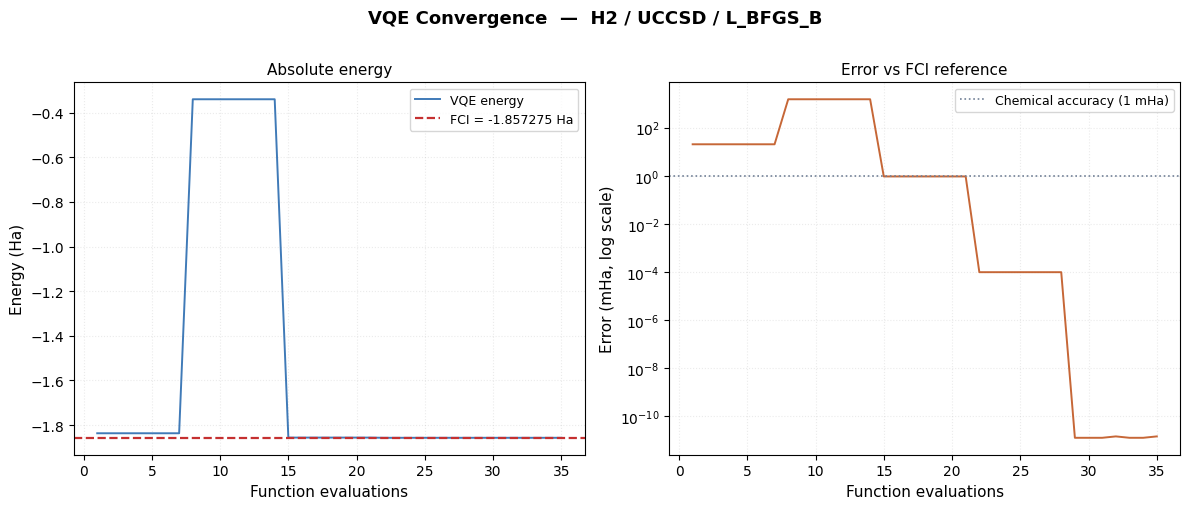

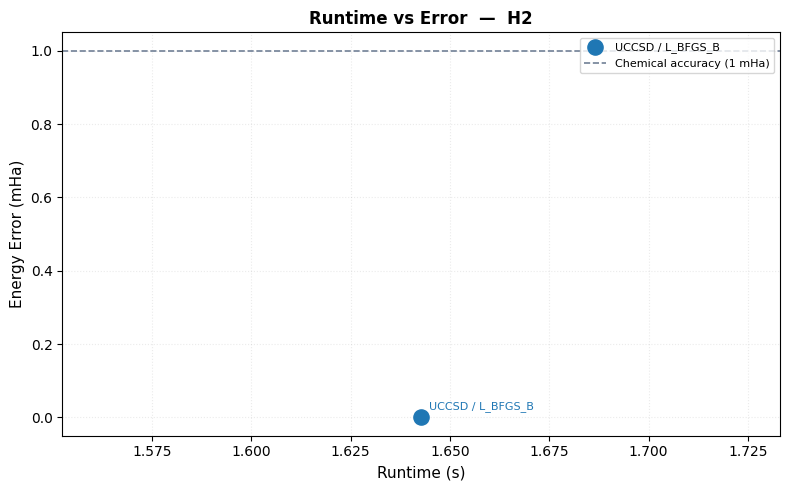

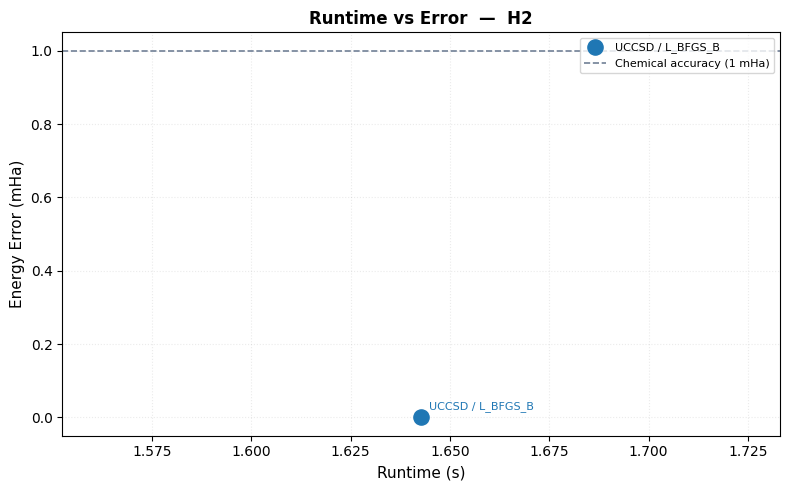


Results appended to : /mgpfs/home/mkhairiansyah/Project/results/H2_sto-3g_uccsd_l_bfgs_b.csv


In [19]:
# ============================================================
# CELL 9 — ANALYSIS, PLOTTING, SAVING
# ============================================================

from IPython.display import display
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from analysis    import (
    compute_energy_error,
    compute_runtime,
    get_circuit_metrics,
    get_problem_metrics,
    create_summary_table,
)
from plotting    import plot_convergence, plot_tradeoff
from save_results import save_results

# ────────────────────────────────────────────────────────────
# 9.1  REFERENCE ENERGY (FCI via NumPy exact diagonalisation)
# ────────────────────────────────────────────────────────────
# NumPyMinimumEigensolver diagonalises the qubit Hamiltonian matrix
# exactly (no shots, no noise). This is FCI quality for the chosen
# basis, orbital space, and qubit mapping — the best achievable energy.
#
# Computational cost scales as 2^n_qubits. Feasible for n ≤ 20 qubits.
# ────────────────────────────────────────────────────────────

print("Computing FCI reference via NumPy eigensolver …")
numpy_solver    = NumPyMinimumEigensolver()
fci_result      = numpy_solver.compute_minimum_eigenvalue(qubit_hamiltonian)
reference_energy = fci_result.eigenvalue.real
print(f"  FCI reference      : {reference_energy:.8f}  Ha")

# ────────────────────────────────────────────────────────────
# 9.2  ENERGY ERROR
# ────────────────────────────────────────────────────────────

errors = compute_energy_error(vqe_energy, reference_energy)

print()
print("=" * 58)
print("   ENERGY SUMMARY")
print("=" * 58)
print(f"  VQE energy          : {vqe_energy:.8f}  Ha")
print(f"  FCI reference       : {reference_energy:.8f}  Ha")
print(f"  Error               : {errors['hartree_error']:.4e}  Ha")
print(f"  Error               : {errors['millihart_error']:.4f}  mHa")
_chem_acc = "✓ chemical accuracy" if errors["millihart_error"] < 1.0 else "✗ above chemical accuracy"
print(f"  Status              : {_chem_acc}  (threshold: 1 mHa)")
print("=" * 58)

# ────────────────────────────────────────────────────────────
# 9.3  PROBLEM AND CIRCUIT METRICS
# ────────────────────────────────────────────────────────────

prob_metrics = get_problem_metrics(problem, mapper)

print()
print("Problem metrics:")
for _k, _v in prob_metrics.items():
    print(f"  {_k:<26}: {_v}")

if IS_ADAPT_VQE:
    # Grown ADAPT ansatz circuit is only available after the run;
    # use pool ansatz metrics as a lower-bound reference.
    circ_metrics = {
        "depth":          "adaptive (grown during run)",
        "num_parameters": "adaptive",
        "cnot_count":     "adaptive",
        "gate_counts":    {},
    }
else:
    circ_metrics = get_circuit_metrics(ansatz)

print()
print("Circuit metrics:")
for _k, _v in circ_metrics.items():
    if _k != "gate_counts":
        print(f"  {_k:<26}: {_v}")
print(f"  {'gate_counts':<26}: {circ_metrics['gate_counts']}")

# ────────────────────────────────────────────────────────────
# 9.4  SUMMARY TABLE
# ────────────────────────────────────────────────────────────

summary_df = create_summary_table(
    experiment=EXPERIMENT,
    vqe_energy=vqe_energy,
    reference_energy=reference_energy,
    runtime=runtime,
    num_evaluations=num_evaluations,
    circuit_metrics=circ_metrics,
    problem_metrics=prob_metrics,
    energy_errors=errors,
)

print()
print("Summary Table (transposed for readability):")
display(summary_df.T)

# ────────────────────────────────────────────────────────────
# 9.5  CONVERGENCE PLOT
# ────────────────────────────────────────────────────────────

plot_convergence(
    energy_history=energy_history,
    reference_energy=reference_energy,
    title=(
        f"VQE Convergence  —  {EXPERIMENT['molecule']} / "
        f"{EXPERIMENT['ansatz'].upper()} / "
        f"{EXPERIMENT['optimizer'].upper()}"
    ),
    figsize=(12, 5),
)

# ────────────────────────────────────────────────────────────
# 9.6  RUNTIME vs ERROR TRADE-OFF PLOT
# ────────────────────────────────────────────────────────────
# For a single run this is a single point.
# Collect (runtime, error, label) tuples across multiple runs and
# call plot_tradeoff with the full lists for a sweep comparison:
#
#   plot_tradeoff(
#       runtime_list=[rt_uccsd, rt_uccgsd, rt_hea],
#       error_list  =[er_uccsd, er_uccgsd, er_hea],
#       labels      =["UCCSD", "UCCGSD", "HEA"],
#   )

plot_tradeoff(
    runtime_list=[runtime],
    error_list=[errors["millihart_error"]],
    labels=[
        f"{EXPERIMENT['ansatz'].upper()} / "
        f"{EXPERIMENT['optimizer'].upper()}"
    ],
    title=f"Runtime vs Error  —  {EXPERIMENT['molecule']}",
)

# ────────────────────────────────────────────────────────────
# 9.7  SAVE RESULTS TO CSV
# ────────────────────────────────────────────────────────────
# In append mode ("a") successive runs accumulate in one file.
# Useful for sweep experiments.

_fname = (
    f"{EXPERIMENT['molecule']}_"
    f"{EXPERIMENT['basis']}_"
    f"{EXPERIMENT['ansatz']}_"
    f"{EXPERIMENT['optimizer']}.csv"
)
results_path = str(RESULTS_DIR / _fname)

saved_to = save_results(results_path, summary_df, mode="a")
print()
print(f"Results appended to : {saved_to}")
